In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../artifacts/Final_dataset_to_ML2.csv')

In [3]:
data.head()

,temp1,temp2,bpm1,bpm2,spo2_1,spo2_2,mpu1_acc_x,mpu1_acc_y,mpu1_acc_z,mpu2_acc_x,...,Occupation_6,Occupation_7,Occupation_8,Occupation_9,Occupation_10,Occupation_11,Occupation_12,Occupation_13,Occupation_14,Occupation_15
0,-0.090943,0.354028,1.676295,1.492223,0.492972,-0.507866,-1.450207,0.109063,-1.441127,0.893865,...,False,False,False,False,False,False,False,False,False,False
1,0.533556,-0.530694,-1.297393,1.288076,0.492972,1.497397,-0.973867,-0.930065,-1.047061,0.724407,...,False,False,False,False,False,False,False,False,False,False
2,0.238654,0.839757,-0.824306,-1.093646,-0.508461,1.497397,0.799609,1.162912,-0.011229,-1.088358,...,False,False,False,False,False,False,False,False,False,False
3,-1.149123,-1.432764,-0.080884,0.131240,0.492972,-0.006551,0.128048,-0.467653,1.345918,-1.020575,...,False,False,False,False,False,False,False,False,False,False
4,1.158056,0.249943,0.459786,0.879781,-1.009177,-0.507866,-0.255453,0.787960,-1.467109,0.174320,...,False,False,False,False,False,False,False,False,False,False


## Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

X = data.drop('stress_level', axis=1)
y = data['stress_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Selection & Training

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9756666666666667
              precision    recall  f1-score   support

           1       1.00      0.72      0.84        85
           2       0.97      1.00      0.99      2485
           3       1.00      0.89      0.94       430

    accuracy                           0.98      3000
   macro avg       0.99      0.87      0.92      3000
weighted avg       0.98      0.98      0.97      3000



In [24]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [25]:
data.head()

,temp1,temp2,bpm1,bpm2,spo2_1,spo2_2,mpu1_acc_x,mpu1_acc_y,mpu1_acc_z,mpu2_acc_x,...,Occupation_6,Occupation_7,Occupation_8,Occupation_9,Occupation_10,Occupation_11,Occupation_12,Occupation_13,Occupation_14,Occupation_15
0,-0.090943,0.354028,1.676295,1.492223,0.492972,-0.507866,-1.450207,0.109063,-1.441127,0.893865,...,False,False,False,False,False,False,False,False,False,False
1,0.533556,-0.530694,-1.297393,1.288076,0.492972,1.497397,-0.973867,-0.930065,-1.047061,0.724407,...,False,False,False,False,False,False,False,False,False,False
2,0.238654,0.839757,-0.824306,-1.093646,-0.508461,1.497397,0.799609,1.162912,-0.011229,-1.088358,...,False,False,False,False,False,False,False,False,False,False
3,-1.149123,-1.432764,-0.080884,0.131240,0.492972,-0.006551,0.128048,-0.467653,1.345918,-1.020575,...,False,False,False,False,False,False,False,False,False,False
4,1.158056,0.249943,0.459786,0.879781,-1.009177,-0.507866,-0.255453,0.787960,-1.467109,0.174320,...,False,False,False,False,False,False,False,False,False,False


## Feature importance

In [27]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Top Features for Stress Prediction")
plt.bar(range(15), importances[indices][:15], align='center')
plt.xticks(range(15), X_train.columns[indices][:15], rotation=90)
plt.show()


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # <-- This step MUST run before accessing feature_importances_

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


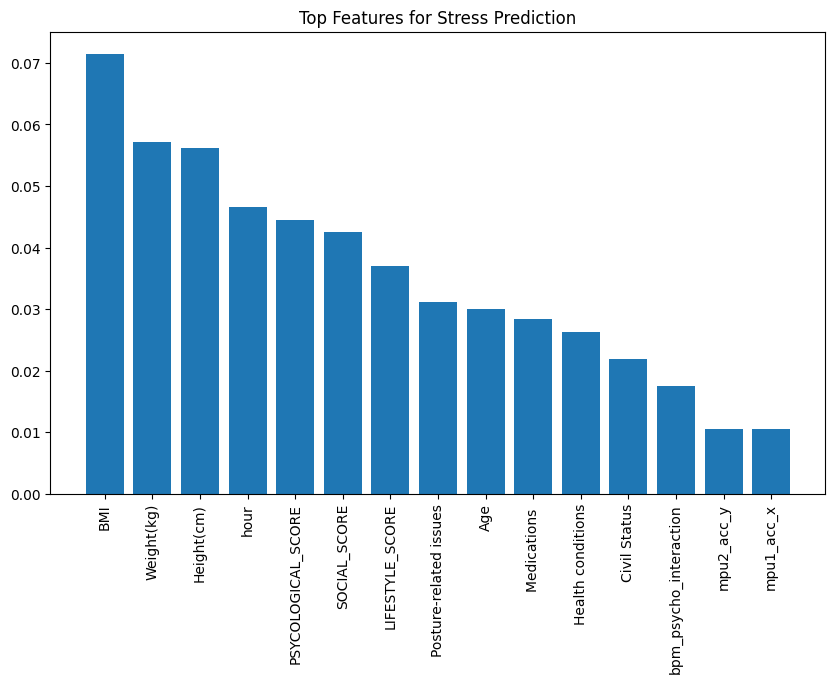

In [31]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Top Features for Stress Prediction")
plt.bar(range(15), importances[indices][:15], align='center')
plt.xticks(range(15), X_train.columns[indices][:15], rotation=90)
plt.show()

In [51]:
import numpy as np

# MPU magnitude
data['mpu1_acc_mag'] = np.sqrt(data['mpu1_acc_x']**2 + data['mpu1_acc_y']**2 + data['mpu1_acc_z']**2)
data['mpu2_acc_mag'] = np.sqrt(data['mpu2_acc_x']**2 + data['mpu2_acc_y']**2 + data['mpu2_acc_z']**2)

# FSR combined
fsr_cols = ['fsr_1','fsr_2','fsr_3','fsr_4','fsr_5','fsr_6','fsr_7','fsr_8','fsr_9','fsr_10','fsr_11','fsr_12']
data['fsr_sum'] = data[fsr_cols].sum(axis=1)
data['fsr_std'] = data[fsr_cols].std(axis=1)

# BPM + Temperature combined magnitude
data['bpm_feature'] = np.sqrt(data['bpm_avg']**2 + data['bpm_diff']**2)
data['temp_feature'] = np.sqrt(data['temp_avg']**2 + data['temp_diff']**2)

# Interaction features (optional)
data['bpm_psycho_interaction'] = data['bpm_avg'] * data['PSYCOLOGICAL_SCORE']

## Feature scaling / normalization

In [52]:
data.head()

,temp1,temp2,bpm1,bpm2,spo2_1,spo2_2,mpu1_acc_x,mpu1_acc_y,mpu1_acc_z,mpu2_acc_x,...,Occupation_8,Occupation_9,Occupation_10,Occupation_11,Occupation_12,Occupation_13,Occupation_14,Occupation_15,bpm_feature,temp_feature
0,-0.090943,0.354028,1.676295,1.492223,0.492972,-0.507866,-1.450207,0.109063,-1.441127,0.893865,...,False,False,False,False,False,False,False,False,108.500156,36.572707
1,0.533556,-0.530694,-1.297393,1.288076,0.492972,1.497397,-0.973867,-0.930065,-1.047061,0.724407,...,False,False,False,False,False,False,False,False,85.039312,36.510514
2,0.238654,0.839757,-0.824306,-1.093646,-0.508461,1.497397,0.799609,1.162912,-0.011229,-1.088358,...,False,False,False,False,False,False,False,False,71.000511,36.809908
3,-1.149123,-1.432764,-0.080884,0.131240,0.492972,-0.006551,0.128048,-0.467653,1.345918,-1.020575,...,False,False,False,False,False,False,False,False,85.500263,35.751125
4,1.158056,0.249943,0.459786,0.879781,-1.009177,-0.507866,-0.255453,0.787960,-1.467109,0.174320,...,False,False,False,False,False,False,False,False,95.000928,36.911173


In [53]:
from sklearn.preprocessing import StandardScaler

sensor_features = ['mpu1_acc_mag','mpu2_acc_mag','fsr_sum','fsr_std','bpm_feature','temp_feature']
other_features = ['BMI','Age','PSYCOLOGICAL_SCORE','LIFESTYLE_SCORE','SOCIAL_SCORE','posture_level']

all_features = sensor_features + other_features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[all_features])

In [54]:
y = data['stress_level']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Model

In [56]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluation

In [57]:
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.78      0.87        85
           2       0.97      1.00      0.99      2485
           3       1.00      0.87      0.93       430

    accuracy                           0.98      3000
   macro avg       0.99      0.88      0.93      3000
weighted avg       0.98      0.98      0.97      3000



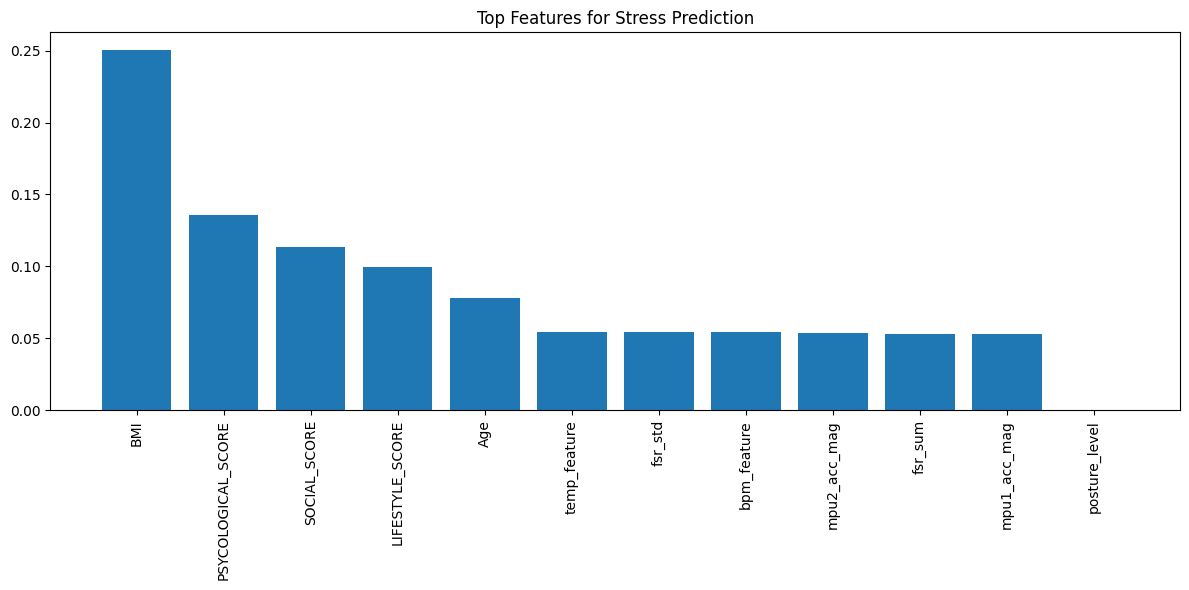

In [58]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Top Features for Stress Prediction")
plt.bar(range(len(all_features)), importances[indices], align='center')
plt.xticks(range(len(all_features)), [all_features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

## Train / Validation / Test split

Example:

70% → Train

15% → Validation

15% → Test


In [59]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(model, X_scaled, y, cv=5)

print("Cross-validation accuracy:", scores.mean())



Cross-validation accuracy: 0.8156000000000001


In [60]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [61]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

# IMPORTANT STEP 👇
model.fit(X_train, y_train)

# Now scoring works
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9753333333333334


In [69]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,       # control depth
    min_samples_leaf=5, # each leaf has at least 5 samples
    random_state=42
)

model.fit(X_train, y_train)

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.9344166666666667
Test Accuracy: 0.894


In [72]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [73]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [75]:
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Create model
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # minority class boost
    random_state=42
)

# 2️⃣ Train
model.fit(X_train, y_train)   # make sure this runs

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))
print(classification_report(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9553333333333334
              precision    recall  f1-score   support

           1       1.00      0.59      0.74        85
           2       0.95      1.00      0.97      2485
           3       1.00      0.77      0.87       430

    accuracy                           0.96      3000
   macro avg       0.98      0.79      0.86      3000
weighted avg       0.96      0.96      0.95      3000



## Top 10 features

In [78]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(10):
    print(all_features[indices[i]], importances[indices[i]])

BMI 0.24545568527022016
PSYCOLOGICAL_SCORE 0.15113102370721113
SOCIAL_SCORE 0.13424915881165225
LIFESTYLE_SCORE 0.11618984865832695
Age 0.10453230701901209
bpm_feature 0.04352955683412485
fsr_std 0.0433194662810384
mpu2_acc_mag 0.040726424555057816
temp_feature 0.040510435338773146
mpu1_acc_mag 0.04027654092804342
